In [ ]:
"Option pricing models - Heston Model via Alternating Direction Implicit (ADI) method"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy import sparse
from scipy.fft import fft
from scipy.interpolate import interp1d
from scipy.stats import norm
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.integrate import quad
from scipy.interpolate import RectBivariateSpline
import scipy.linalg as linalg
import scipy.optimize as optimize

import warnings
warnings.filterwarnings('ignore')

# --- Option Pricing Calculations ---

# --- 1. Define Heston Model, Option, and Grid Parameters and Option Details ---

# Model parameters
v0 = 0.04       # Initial variance (20% volatility)
theta = 0.04    # Long-run variance
kappa = 2.0     # Speed of mean reversion
sigma = 0.3     # Volatility of variance ('vol of vol')
rho = -0.7      # Correlation between asset and variance (typically negative)
#Market Option parameters
S0 = 100.0      # Initial stock price
K = 100.0       # Strike price
T = 1.0         # Time to maturity (1 year)
r = 0.03        # Risk-free rate (3%)
q = 0.02        # Dividend yield (2%)

# Grid parameters
N_S = 200       # Number of stock price steps
N_v = 50        # Number of variance steps
N_t = 100       # Number of time steps
S_max = 2 * K   # Max stock price
v_max = 0.5     # Max variance

In [3]:
# --- 2. Define Pricing Function ---

def price_american_put_heston_hv_banded(params, option_params, grid_params):
    """
    Prices an American put using the stable Hundsdorfer-Verwer ADI scheme,
    solved with linalg.solve_banded
    """
    # Unpack parameters
    v0, theta, kappa, sigma, rho = params
    K, T, r, S0 = option_params
    N_S, N_v, N_t, S_max, v_max = grid_params

    # Create Discretization Grids
    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)
    t_grid = np.linspace(0, T, N_t + 1)
    
    dS = S_grid[1] - S_grid[0]
    dv = v_grid[1] - v_grid[0]
    dt = t_grid[1] - t_grid[0]
    
    # Initialize grid for option values
    V = np.zeros((N_S + 1, N_v + 1))
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')
    
    # Set terminal condition (payoff at maturity)
    V = np.maximum(K - S_mat, 0)
    
    # Backward Time Iteration Loop (Hundsdorfer-Verwer Scheme)
    theta_hv = 1 - (np.sqrt(2) / 2) # HV stability parameter
    
    for n in range(N_t, 0, -1):
        V_n = V.copy() # Solution at current time n

        # Apply boundary conditions
        V[0, :] = K * np.exp(-r * (T - t_grid[n-1]))
        V[-1, :] = 0
        V[:, 0] = V[:, 1]  # Neumann condition at v=0 (can be a source of instability if not careful)
        V[:, -1] = V[:, -2]

        # Stage 1: Explicit Predictor (Y0)
        LS_Vn, LV_Vn, LSV_Vn = np.zeros_like(V_n), np.zeros_like(V_n), np.zeros_like(V_n)

        # Calculate effect of operators L_S, L_v, L_sv on V_n
        # This approach builds the result vector directly without creating full matrices
        for i in range(1, N_S):
            for j in range(1, N_v):
                d2V_dS2 = (V_n[i+1, j] - 2*V_n[i, j] + V_n[i-1, j]) / dS**2
                dV_dS = (V_n[i+1, j] - V_n[i-1, j]) / (2*dS)
                LS_Vn[i, j] = 0.5*v_grid[j]*S_grid[i]**2*d2V_dS2 + r*S_grid[i]*dV_dS - r*V_n[i, j]

                d2V_dv2 = (V_n[i, j+1] - 2*V_n[i, j] + V_n[i, j-1]) / dv**2
                dV_dv = (V_n[i, j+1] - V_n[i, j-1]) / (2*dv)
                LV_Vn[i, j] = 0.5*sigma**2*v_grid[j]*d2V_dv2 + kappa*(theta-v_grid[j])*dV_dv
                
                d2V_dSdv = (V_n[i+1,j+1] - V_n[i-1,j+1] - V_n[i+1,j-1] + V_n[i-1,j-1]) / (4*dS*dv)
                LSV_Vn[i, j] = rho*sigma*v_grid[j]*S_grid[i]*d2V_dSdv

        Y0 = V_n + dt * (LS_Vn + LV_Vn + LSV_Vn)
        
        # Stage 2: Implicit S-Correction (Y1)
        Y1 = Y0.copy()
        for j in range(1, N_v):
            vj = v_grid[j]
            alpha_S = 0.5*vj*S_grid[1:-1]**2/dS**2 - r*S_grid[1:-1]/(2*dS)
            beta_S = -vj*S_grid[1:-1]**2/dS**2 - r
            gamma_S = 0.5*vj*S_grid[1:-1]**2/dS**2 + r*S_grid[1:-1]/(2*dS)
            
            # LHS Matrix (I - theta*dt*L_S) in banded format
            ab_S = np.zeros((3, N_S - 1))
            ab_S[0, 1:] = -theta_hv * dt * gamma_S[:-1]
            ab_S[1, :] = 1 - theta_hv * dt * beta_S
            ab_S[2, :-1] = -theta_hv * dt * alpha_S[1:]

            # RHS Vector
            RHS_S = Y0[1:-1, j] - theta_hv * dt * LS_Vn[1:-1, j]
            Y1[1:-1, j] = linalg.solve_banded((1, 1), ab_S, RHS_S)

        # Stage 3: Implicit V-Correction (V_next)
        V_next = Y1.copy()
        for i in range(1, N_S):
            Si = S_grid[i]
            alpha_v = 0.5*sigma**2*v_grid[1:-1]/dv**2 - kappa*(theta-v_grid[1:-1])/(2*dv)
            beta_v = -sigma**2*v_grid[1:-1]/dv**2
            gamma_v = 0.5*sigma**2*v_grid[1:-1]/dv**2 + kappa*(theta-v_grid[1:-1])/(2*dv)
            
            # LHS Matrix (I - theta*dt*L_v) in banded format
            ab_v = np.zeros((3, N_v - 1))
            ab_v[0, 1:] = -theta_hv * dt * gamma_v[:-1]
            ab_v[1, :] = 1 - theta_hv * dt * beta_v
            ab_v[2, :-1] = -theta_hv * dt * alpha_v[1:]
            
            # RHS Vector
            RHS_v = Y1[i, 1:-1] - theta_hv * dt * LV_Vn[i, 1:-1]
            V_next[i, 1:-1] = linalg.solve_banded((1, 1), ab_v, RHS_v)

        # Enforce American Early Exercise
        payoff = np.maximum(K - S_mat, 0)
        V = np.maximum(V_next, payoff)

    # Interpolate to find price at (S0, v0)
    spline = RectBivariateSpline(S_grid, v_grid, V)
    price = spline(S0, v0)[0][0]
    
    return price, V

--- Heston American Put Price (HV Scheme with solve_banded) ---
Grid Size (S x v x t): 200 x 50 x 100
Option Price at S0=100.0, v0=0.04: -0.0000



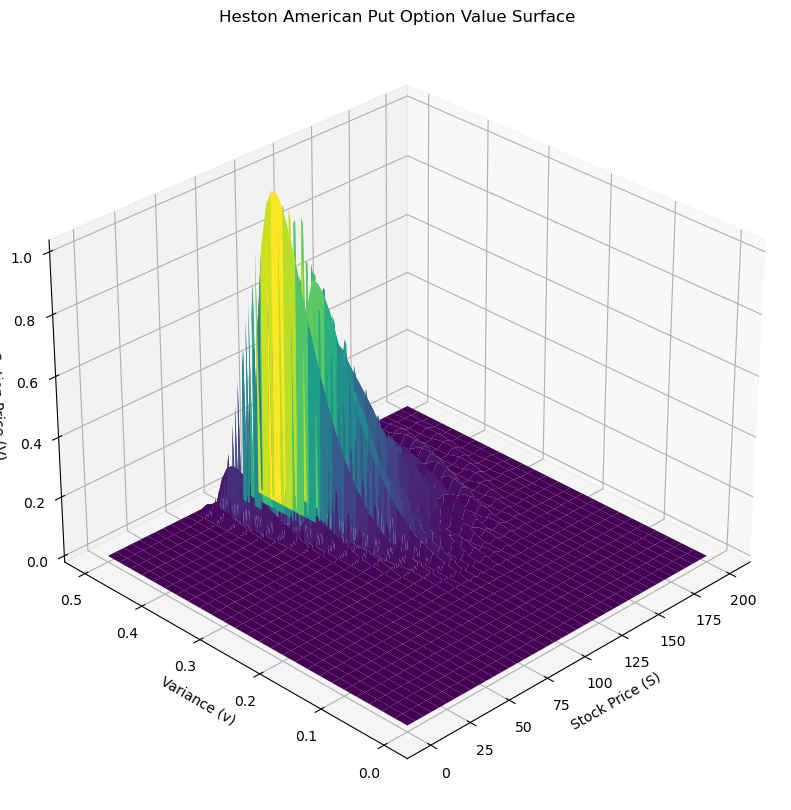

In [ ]:
# --- 3. Run Optimization Function and visualize results ---

if __name__ == '__main__':
    # Pack parameters into tuples
    model_params = (v0, theta, kappa, sigma, rho)
    option_params = (K, T, r, S0)
    grid_params = (N_S, N_v, N_t, S_max, v_max)

    S_grid = np.linspace(0, S_max, N_S + 1)
    v_grid = np.linspace(0, v_max, N_v + 1)

    # Calculate the price
    price, V_surface = price_american_put_heston_hv_banded(model_params, option_params, grid_params)
    
    print("--- Heston American Put Price (HV Scheme with solve_banded) ---")
    print(f"Grid Size (S x v x t): {N_S} x {N_v} x {N_t}")
    print(f"Option Price at S0={S0}, v0={v0}: {price:.4f}\n")
    
    # Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')

    ax.plot_surface(S_mat, v_mat, V_surface, cmap='viridis')
    ax.set_title("Heston American Put Option Value Surface")
    ax.set_xlabel("Stock Price (S)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Option Price (V)")
    ax.view_init(30, -135) # Adjust viewing angle
    plt.show()
    

In [5]:
# --- 4. Option Pricing via ADI using spsolve instead of solve_banded ---

#  Grid Parameters

S_grid = np.linspace(0, S_max, N_S + 1)
v_grid = np.linspace(0, v_max, N_v + 1)
t_grid = np.linspace(0, T, N_t + 1)

dS = S_grid[1] - S_grid[0]
dv = v_grid[1] - v_grid[0]
dt = t_grid[1] - t_grid[0]

# Define Main Pricing Function using spsolve

def price_american_put_heston_spsolve(S0, K, T, r, v0, theta, kappa, sigma, rho,
                                      S_grid, v_grid, t_grid):
    """
    Prices an American put option using the Heston model,
    solving the linear systems with scipy.sparse.linalg.spsolve
    """
    N_S = len(S_grid) - 1
    N_v = len(v_grid) - 1
    N_t = len(t_grid) - 1
    
    V = np.zeros((N_S + 1, N_v + 1))
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')
    V = np.maximum(K - S_mat, 0)
    
    for n in range(N_t, 0, -1):
        # Intermediate Step (Y)
        Y = np.zeros_like(V)
        
        for j in range(1, N_v):
            vj = v_grid[j]
            
            alpha_S = 0.25 * dt * (vj * S_grid[1:-1]**2 / dS**2 - r * S_grid[1:-1] / dS)
            beta_S = -0.5 * dt * (vj * S_grid[1:-1]**2 / dS**2 + r)
            gamma_S = 0.25 * dt * (vj * S_grid[1:-1]**2 / dS**2 + r * S_grid[1:-1] / dS)
            
            # Create A_S as a sparse matrix using diags
            diagonals_S = [-alpha_S[1:], 1 - beta_S, -gamma_S[:-1]]
            offsets = [-1, 0, 1]
            A_S_sparse = diags(diagonals_S, offsets, shape=(N_S - 1, N_S - 1), format='csc')
            
            # Setup RHS (Right-Hand Side)
            B_S_V = (V[1:-1, j] + 
                     alpha_S * V[:-2, j] + 
                     beta_S * V[1:-1, j] + 
                     gamma_S * V[2:, j])

            dv_V = (V[1:-1, j+1] - V[1:-1, j-1]) / (2 * dv)
            d2v_V = (V[1:-1, j+1] - 2 * V[1:-1, j] + V[1:-1, j-1]) / dv**2
            dSv_V = (V[2:, j+1] - V[:-2, j+1] - V[2:, j-1] + V[:-2, j-1]) / (4 * dS * dv)

            L_v_V = (0.5 * sigma**2 * vj * d2v_V + kappa * (theta - vj) * dv_V +
                     0.5 * rho * sigma * vj * S_grid[1:-1] * dSv_V)
            
            rhs = B_S_V + dt * L_v_V

            rhs[0] += 2 * alpha_S[0] * K 
            rhs[-1] += 2 * gamma_S[-1] * 0
            
            # Solve using spsolve
            Y[1:-1, j] = spsolve(A_S_sparse, rhs)

        Y[0, :] = K
        Y[-1, :] = 0
        Y[:, 0] = K * np.exp(-r * (T - t_grid[n-1]))
        Y[:, -1] = Y[:, -2]
        
        # Final Step (V)
        for i in range(1, N_S):
            Si = S_grid[i]
            
            alpha_v = 0.25 * dt * (sigma**2 * v_grid[1:-1] / dv**2 - kappa * (theta - v_grid[1:-1]) / dv)
            beta_v = -0.5 * dt * (sigma**2 * v_grid[1:-1] / dv**2 + r)
            gamma_v = 0.25 * dt * (sigma**2 * v_grid[1:-1] / dv**2 + kappa * (theta - v_grid[1:-1]) / dv)

            # Create A_v as a sparse matrix using diags
            diagonals_v = [-alpha_v[1:], 1 - beta_v, -gamma_v[:-1]]
            offsets_v = [-1, 0, 1]
            A_v_sparse = diags(diagonals_v, offsets_v, shape=(N_v - 1, N_v - 1), format='csc')

            dS_Y = (Y[i+1, 1:-1] - Y[i-1, 1:-1]) / (2 * dS)
            d2S_Y = (Y[i+1, 1:-1] - 2 * Y[i, 1:-1] + Y[i-1, 1:-1]) / dS**2
            
            L_S_V = 0.5 * v_grid[1:-1] * Si**2 * d2S_Y + r * Si * dS_Y - 0.5 * r * V[i, 1:-1]
            L_S_Y = 0.5 * v_grid[1:-1] * Si**2 * d2S_Y + r * Si * dS_Y - 0.5 * r * Y[i, 1:-1]
            
            # B_v_V is the explicit part for the v-direction
            B_v_V = V[i, 1:-1] + alpha_v*V[i, :-2] + beta_v*V[i, 1:-1] + gamma_v*V[i, 2:]
            
            rhs_v = B_v_V + (L_S_Y - L_S_V)
            
            rhs_v[0] += 2 * alpha_v[0] * (K * np.exp(-r * (T - t_grid[n-1])) - Y[i,0])
            
            # Solve using spsolve
            V[i, 1:-1] = spsolve(A_v_sparse, rhs_v)
            
        intrinsic_value = np.maximum(K - S_mat, 0)
        V = np.maximum(V, intrinsic_value)

    spline = RectBivariateSpline(S_grid, v_grid, V)
    price = spline(S0, v0)[0][0]
    
    return price, V


Heston Model Parameters:
v0=0.03, theta=0.03, kappa=1.5, sigma=0.6, rho=-0.67, r=0.03, T=1.0

Grid Size: 200 (Stock Price) x 50 (Variance) x 100 (Time)
Price for an at-the-money (S0=100.0, K=100.0) American Put Option: -0.0000


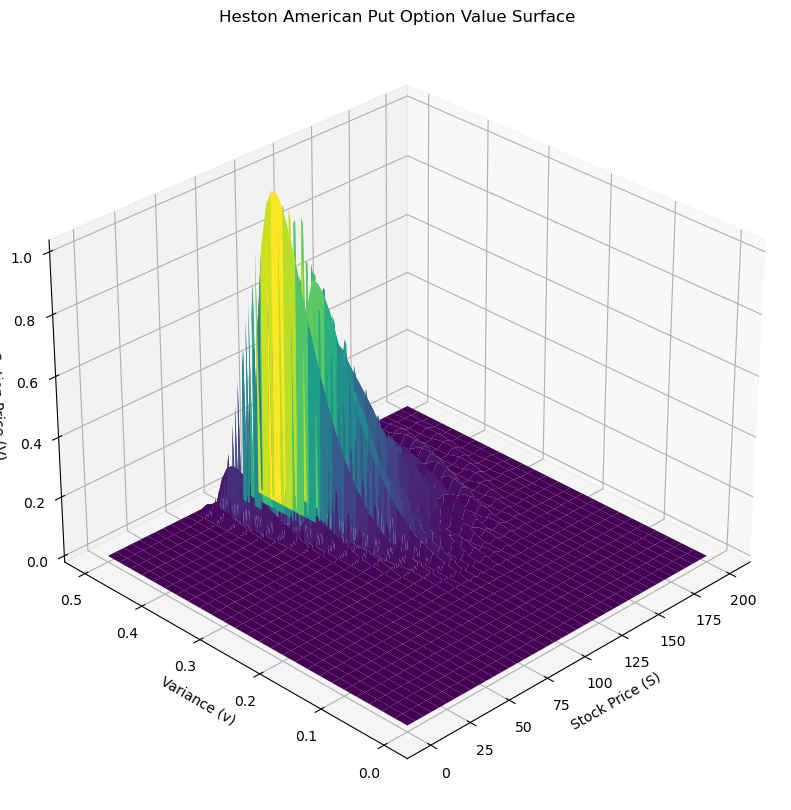

In [7]:
# --- 5. Price the option and visualize the results ---

v0, theta, kappa, sigma, rho = [0.03, 0.03, 1.5, 0.6, -0.67]

if __name__ == '__main__':
    price, V_grid = price_american_put_heston_spsolve(S0, K, T, r, v0, theta, kappa, sigma, rho,
                                                      S_grid, v_grid, t_grid)
    
    print(f"Heston Model Parameters:")
    print(f"v0={v0}, theta={theta}, kappa={kappa}, sigma={sigma}, rho={rho}, r={r}, T={T}\n")
    print(f"Grid Size: {N_S} (Stock Price) x {N_v} (Variance) x {N_t} (Time)")
    print(f"Price for an at-the-money (S0={S0}, K={K}) American Put Option: {price:.4f}")

    # Plotting
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    S_mat, v_mat = np.meshgrid(S_grid, v_grid, indexing='ij')

    ax.plot_surface(S_mat, v_mat, V_surface, cmap='viridis')
    ax.set_title("Heston American Put Option Value Surface")
    ax.set_xlabel("Stock Price (S)")
    ax.set_ylabel("Variance (v)")
    ax.set_zlabel("Option Price (V)")
    ax.view_init(30, -135) # Adjust viewing angle
    plt.show()